In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from simulators import ContextManager, NestedModelFamily
from simulators.benchmarks.ddms import DDM
from simulators.benchmarks.ddms import sample_ddm_prior

In [3]:
parameter_names = [
    "v_intercept", "v_slope", "s_v",
    "a_intercept", "a_slope", "decay",
    "tau", "s_tau",
]

In [4]:
context_manager = ContextManager(parameter_names=parameter_names)

In [5]:
num_samples = 500
design_matrix = np.random.normal(0.0, 1.0, size=(num_samples, 2)).astype(np.float32)

In [6]:
model_family = NestedModelFamily(
    name="ddm",
    model=DDM,
    context_manager=context_manager,
    prior_fun=sample_ddm_prior,
    num_samples=num_samples
)

### Priors

In [7]:
# Run multiple configs in one go
configs = [
    {"s_v", "s_tau"},                # fix variability terms
    {"s_v"},
    {"s_tau"},# fix only s_v
    set(),                           # all free
    {"v_intercept", "a_slope"},       # cfg1: zero out these
    {"tau", "s_tau", "decay"},        # cfg2: zero out these
]

context_variables={
    "x_v": design_matrix[:, 0],
    "x_a": design_matrix[:, 1],
}

In [8]:
results = model_family.sample(configs, context=context_variables)

{'v_intercept': np.float32(0.7527472), 'v_slope': np.float32(3.1515129), 's_v': np.float32(0.0), 'a_intercept': np.float32(3.5113776), 'a_slope': np.float32(-1.5602252), 'decay': np.float32(0.45817098), 'tau': np.float32(0.4482381), 's_tau': np.float32(0.0)}
{'v_intercept': np.float32(1.5380722), 'v_slope': np.float32(6.345123), 's_v': np.float32(0.0), 'a_intercept': np.float32(2.9404166), 'a_slope': np.float32(-0.28496766), 'decay': np.float32(0.20856048), 'tau': np.float32(0.43301427), 's_tau': np.float32(0.36053377)}
{'v_intercept': np.float32(2.4219623), 'v_slope': np.float32(1.9220767), 's_v': np.float32(0.9611882), 'a_intercept': np.float32(2.678669), 'a_slope': np.float32(1.2646314), 'decay': np.float32(0.29370314), 'tau': np.float32(0.34027076), 's_tau': np.float32(0.0)}
{'v_intercept': np.float32(2.1982863), 'v_slope': np.float32(3.7306237), 's_v': np.float32(0.4476228), 'a_intercept': np.float32(2.4622633), 'a_slope': np.float32(0.27973843), 'decay': np.float32(0.02793927), '

In [9]:
results

[{'variant_name': 'ddm|cfg1',
  'fixed_parameters': ['s_v', 's_tau'],
  'mask': {'v_intercept': 1.0,
   'v_slope': 1.0,
   's_v': 0.0,
   'a_intercept': 1.0,
   'a_slope': 1.0,
   'decay': 1.0,
   'tau': 1.0,
   's_tau': 0.0},
  'prior_draw': array([ 0.7527472 ,  3.1515129 ,  0.39440516,  3.5113776 , -1.5602252 ,
          0.45817098,  0.4482381 ,  0.78823954], dtype=float32),
  'full_params': {'v_intercept': np.float32(0.7527472),
   'v_slope': np.float32(3.1515129),
   's_v': np.float32(0.0),
   'a_intercept': np.float32(3.5113776),
   'a_slope': np.float32(-1.5602252),
   'decay': np.float32(0.45817098),
   'tau': np.float32(0.4482381),
   's_tau': np.float32(0.0)},
  'sim_data': {'rts': array([1.8152381 , 0.7142381 , 0.5302381 , 0.5772381 , 0.6542381 ,
          0.7192381 , 0.6762381 , 2.2862382 , 1.0812382 , 0.91123813,
          0.9062381 , 0.46123812, 1.0482382 , 0.5262381 , 0.9342381 ,
          0.9492381 , 0.61523813, 0.5122381 , 0.4862381 , 0.6102381 ,
          0.67523813, 1

In [10]:
rts_list = []
titles = []
for i, res in enumerate(results, 1):
    fp = res["full_params"]
    sim = res["sim_data"]
    assert "rts" in sim and "choices" in sim
    assert sim["rts"].shape == (num_samples,)
    assert sim["choices"].shape == (num_samples,)
    rts = sim["rts"]
    # Filter out timeouts if any (-1.0)
    rts = rts[rts > 0]
    rts_list.append(rts)
    titles.append(f"Config {i}")

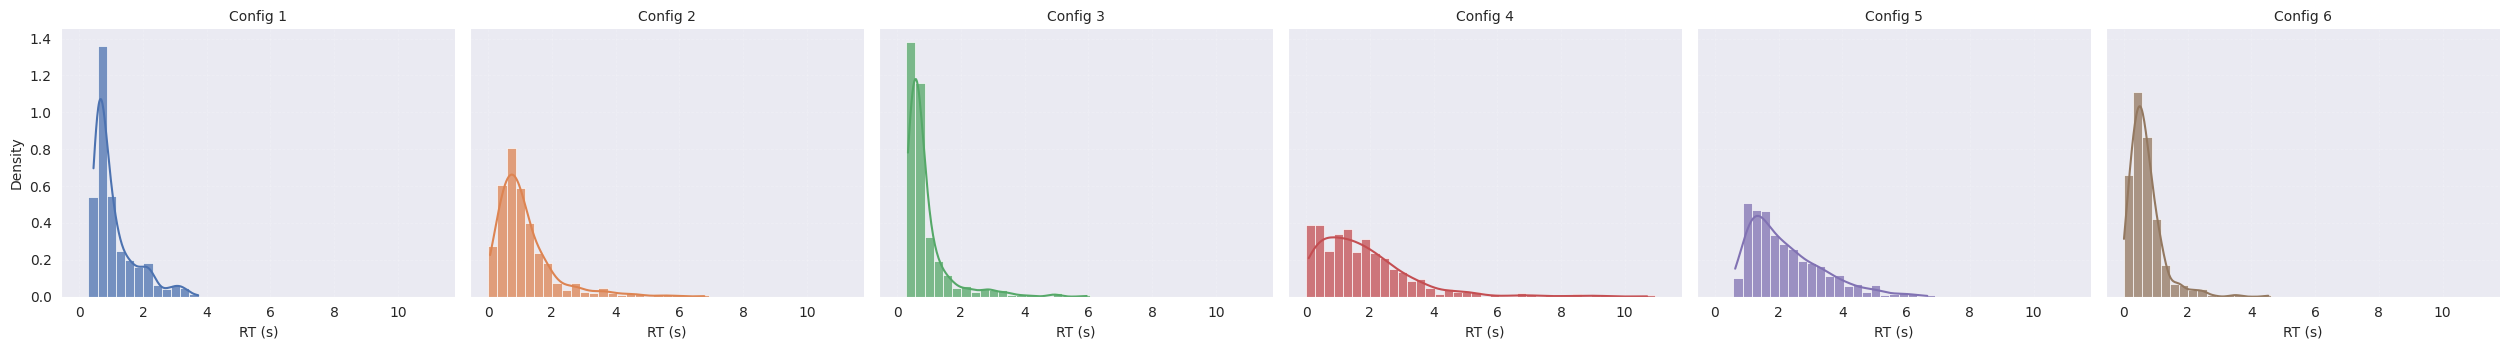

In [11]:
n = len(rts_list)
fig, axes = plt.subplots(1, n, figsize=(4.2*n, 3.6), sharey=True)
if n == 1:
    axes = [axes]

bins = np.linspace(0.0, max(max(r) for r in rts_list)*1.05, 40)
palette = sns.color_palette("deep", n)

for ax, rts, title, color in zip(axes, rts_list, titles, palette):
    sns.histplot(rts, bins=bins, stat="density", ax=ax,
                 color=color, alpha=0.75, edgecolor=None, kde=True)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("RT (s)")
    ax.grid(alpha=0.2, linestyle="--", linewidth=0.6)
    sns.despine(ax=ax)

axes[0].set_ylabel("Density")
fig.tight_layout()

In [12]:
always_free = {"v_intercept", "a_intercept", "tau"}  # define once
K = 5                      # number of random configs to generate
p_free = 0.5               # probability for non-always-free to be free
N = 200                    # trials per simulation

In [15]:
fixed_configs = []
for _ in range(K):
    mask = context_manager.build_random_mask(free_parameters=always_free, p_free=p_free)
    fixed = [name for name, m in mask.items() if m == 0.0]   # NestedModelFamily expects *fixed* names
    fixed_configs.append(fixed)

In [16]:
fixed_configs

[['s_tau'],
 ['decay', 's_tau'],
 ['v_slope', 's_v', 'a_slope', 'decay'],
 ['v_slope', 'decay'],
 ['v_slope', 'a_slope']]

In [18]:
x_v = np.random.normal(size=N).astype(np.float32)
x_a = np.random.normal(size=N).astype(np.float32)
context = {"x_v": x_v, "x_a": x_a}

In [19]:
family = NestedModelFamily(
    name="ddm",
    model=DDM,
    context_manager=context_manager,
    prior_fun=sample_ddm_prior,
    num_samples=N,
)

In [20]:
results = family.sample(fixed_configs=fixed_configs, num_samples=N, context=context)

{'v_intercept': np.float32(2.2666411), 'v_slope': np.float32(0.6098104), 's_v': np.float32(0.26548624), 'a_intercept': np.float32(1.4997805), 'a_slope': np.float32(0.4475133), 'decay': np.float32(0.5116264), 'tau': np.float32(0.63168967), 's_tau': np.float32(0.0)}
{'v_intercept': np.float32(2.650148), 'v_slope': np.float32(-3.8213618), 's_v': np.float32(0.1421068), 'a_intercept': np.float32(2.5830588), 'a_slope': np.float32(-0.6237932), 'decay': np.float32(0.0), 'tau': np.float32(0.27649963), 's_tau': np.float32(0.0)}
{'v_intercept': np.float32(0.8555633), 'v_slope': np.float32(0.0), 's_v': np.float32(0.0), 'a_intercept': np.float32(1.7869669), 'a_slope': np.float32(0.0), 'decay': np.float32(0.0), 'tau': np.float32(0.76801634), 's_tau': np.float32(0.9312707)}
{'v_intercept': np.float32(1.7591573), 'v_slope': np.float32(0.0), 's_v': np.float32(0.48514485), 'a_intercept': np.float32(1.8159194), 'a_slope': np.float32(-0.74303013), 'decay': np.float32(0.0), 'tau': np.float32(0.4655838), 's

In [21]:
for i, res in enumerate(results, 1):
    print(f"\nConfig {i}")
    print("  Fixed params:", res["fixed_parameters"])
    print("  Mask (excerpt):", {k: res["mask"][k] for k in ["v_intercept","v_slope","a_intercept","a_slope","tau"]})
    print("  RTs shape:", res["sim_data"]["rts"].shape)


Config 1
  Fixed params: ['s_tau']
  Mask (excerpt): {'v_intercept': 1.0, 'v_slope': 1.0, 'a_intercept': 1.0, 'a_slope': 1.0, 'tau': 1.0}
  RTs shape: (200,)

Config 2
  Fixed params: ['decay', 's_tau']
  Mask (excerpt): {'v_intercept': 1.0, 'v_slope': 1.0, 'a_intercept': 1.0, 'a_slope': 1.0, 'tau': 1.0}
  RTs shape: (200,)

Config 3
  Fixed params: ['v_slope', 's_v', 'a_slope', 'decay']
  Mask (excerpt): {'v_intercept': 1.0, 'v_slope': 0.0, 'a_intercept': 1.0, 'a_slope': 0.0, 'tau': 1.0}
  RTs shape: (200,)

Config 4
  Fixed params: ['v_slope', 'decay']
  Mask (excerpt): {'v_intercept': 1.0, 'v_slope': 0.0, 'a_intercept': 1.0, 'a_slope': 1.0, 'tau': 1.0}
  RTs shape: (200,)

Config 5
  Fixed params: ['v_slope', 'a_slope']
  Mask (excerpt): {'v_intercept': 1.0, 'v_slope': 0.0, 'a_intercept': 1.0, 'a_slope': 0.0, 'tau': 1.0}
  RTs shape: (200,)


In [28]:
intrinsics = ["v", "a", "tau", "s_v", "s_tau", "decay"]
design_config = {
    "1": intrinsics,
    "u_1": ["v"],
    "u_2": ["v", "a"]
}

design_matrix = model_family.generate_design_matrix(design_config=design_config, num_samples=N)

3
(200, 3)


In [33]:
param_mask = model_family.generate_param_mask(design_config=design_config, parameter_names=parameter_names)

In [34]:
param_mask

array([[1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [35]:
import numpy as np

In [37]:
(np.random.rand(3) < 0.5).astype(int)

array([1, 0, 1])